# Adversarial Attack on Traffic Light Classification

This notebook demonstrates how a small, imperceptible perturbation can fool a neural network into misclassifying a traffic light as a daisy (plant). We use Foolbox, a Python library for creating adversarial examples.

In [1]:
# Install dependencies (uncomment if needed)
# !pip install foolbox torch torchvision matplotlib pillow

In [2]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import foolbox as fb
import urllib.request
import json
import os
import ssl

# Set device for model inference
if torch.cuda.is_available():
    device = torch.device('cuda')
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

# Foolbox doesn't fully support MPS — always use CPU for attacks
attack_device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

print(f"Inference device: {device}")
print(f"Attack device:    {attack_device}")

Inference device: mps
Attack device:    cpu


## Load a Pretrained Model

We'll use ResNet-18 pretrained on ImageNet. This model knows 1000 classes including traffic lights (class 920) and various plants like daisy (class 986).

In [3]:
# Load pretrained ResNet-18 (cache to models/ dir)
MODEL_DIR = "models"
MODEL_PATH = os.path.join(MODEL_DIR, "resnet18_imagenet.pth")

os.makedirs(MODEL_DIR, exist_ok=True)

if os.path.exists(MODEL_PATH):
    print(f"Loading model from {MODEL_PATH}...")
    model = models.resnet18()
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device, weights_only=True))
else:
    print("Downloading pretrained ResNet-18...")
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    torch.save(model.state_dict(), MODEL_PATH)
    print(f"Model saved to {MODEL_PATH}")

model = model.eval().to(device)

# Load ImageNet class labels (with SSL fallback for macOS)
LABELS_URL = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
LABELS_PATH = "imagenet_classes.txt"

if not os.path.exists(LABELS_PATH):
    try:
        urllib.request.urlretrieve(LABELS_URL, LABELS_PATH)
    except urllib.error.URLError:
        # SSL fallback — common on macOS without certs installed
        ctx = ssl.create_default_context()
        ctx.check_hostname = False
        ctx.verify_mode = ssl.CERT_NONE
        with urllib.request.urlopen(LABELS_URL, context=ctx) as resp:
            with open(LABELS_PATH, "wb") as f:
                f.write(resp.read())
        print("(downloaded with SSL verification disabled)")

with open(LABELS_PATH) as f:
    imagenet_labels = [line.strip() for line in f.readlines()]

# Key classes we care about
TRAFFIC_LIGHT_CLASS = 920  # traffic light
TREE_CLASS = 988 

print(f"Traffic light class ({TRAFFIC_LIGHT_CLASS}): {imagenet_labels[TRAFFIC_LIGHT_CLASS]}")
print(f"Target plant class ({TREE_CLASS}): {imagenet_labels[TREE_CLASS]}")

Loading model from models/resnet18_imagenet.pth...
Traffic light class (920): traffic light
Target plant class (988): acorn


In [4]:
# Explore all tree/plant-related ImageNet labels
tree_plant_keywords = ['acorn']

print("Tree/plant-related ImageNet classes:")
print("-" * 50)
matches = []
for idx, label in enumerate(imagenet_labels):
    if any(kw in label.lower() for kw in tree_plant_keywords):
        matches.append((idx, label))
        print(f"  Class {idx:4d}: {label}")

print(f"\nTotal matches: {len(matches)}")
print(f"\nCurrently using target: class {TREE_CLASS} ({imagenet_labels[TREE_CLASS]})")

Tree/plant-related ImageNet classes:
--------------------------------------------------
  Class  941: acorn squash
  Class  988: acorn

Total matches: 2

Currently using target: class 988 (acorn)


## Create a Synthetic Traffic Light Image

We'll create a simple but recognizable traffic light image that the model can classify correctly.

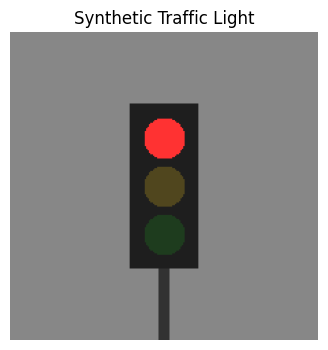

In [5]:
def create_traffic_light_image(size=224):
    """Create a simple traffic light image."""
    img = np.ones((size, size, 3), dtype=np.uint8) * 135  # Gray sky background
    
    # Traffic light housing (black rectangle)
    center_x = size // 2
    box_width, box_height = 50, 120
    y_start = (size - box_height) // 2
    
    # Draw black housing
    img[y_start:y_start+box_height, 
        center_x-box_width//2:center_x+box_width//2] = [30, 30, 30]
    
    # Draw the three lights
    light_radius = 15
    light_spacing = 35
    
    # Red light (top) - lit
    cy = y_start + 25
    for y in range(cy-light_radius, cy+light_radius):
        for x in range(center_x-light_radius, center_x+light_radius):
            if (x-center_x)**2 + (y-cy)**2 < light_radius**2:
                img[y, x] = [255, 50, 50]  # Bright red
    
    # Yellow light (middle) - dim
    cy = y_start + 25 + light_spacing
    for y in range(cy-light_radius, cy+light_radius):
        for x in range(center_x-light_radius, center_x+light_radius):
            if (x-center_x)**2 + (y-cy)**2 < light_radius**2:
                img[y, x] = [80, 70, 30]  # Dim yellow
    
    # Green light (bottom) - dim
    cy = y_start + 25 + 2*light_spacing
    for y in range(cy-light_radius, cy+light_radius):
        for x in range(center_x-light_radius, center_x+light_radius):
            if (x-center_x)**2 + (y-cy)**2 < light_radius**2:
                img[y, x] = [30, 60, 30]  # Dim green
    
    # Pole
    pole_width = 8
    img[y_start+box_height:, center_x-pole_width//2:center_x+pole_width//2] = [50, 50, 50]
    
    return img

# Create and display the traffic light
traffic_light_np = create_traffic_light_image()
plt.figure(figsize=(4, 4))
plt.imshow(traffic_light_np)
plt.axis('off')
plt.title('Synthetic Traffic Light')
plt.show()

## Preprocess and Classify the Original Image

In [6]:
# ImageNet preprocessing
preprocess = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225]),
])

# Convert to tensor
traffic_light_pil = Image.fromarray(traffic_light_np)
input_tensor = preprocess(traffic_light_pil).unsqueeze(0).to(device)

# Get prediction
with torch.no_grad():
    output = model(input_tensor)
    probabilities = torch.nn.functional.softmax(output[0], dim=0)
    
# Top 5 predictions
top5_prob, top5_idx = torch.topk(probabilities, 5)
print("Original image - Top 5 predictions:")
for prob, idx in zip(top5_prob, top5_idx):
    print(f"  {imagenet_labels[idx]}: {prob.item()*100:.2f}%")

Original image - Top 5 predictions:
  traffic light: 93.79%
  street sign: 0.91%
  switch: 0.74%
  loudspeaker: 0.60%
  digital clock: 0.52%


## Create the Adversarial Attack

We'll use Foolbox's Projected Gradient Descent (PGD) attack to create a targeted adversarial example that makes the model predict "daisy" instead of "traffic light".

In [7]:
# Wrap model for Foolbox (runs on attack_device — CPU or CUDA, not MPS)
raw_tensor = torch.from_numpy(traffic_light_np).permute(2, 0, 1).float() / 255.0
raw_tensor = raw_tensor.unsqueeze(0).to(attack_device)

class PreprocessedModel(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
        self.register_buffer('mean', torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1))
        self.register_buffer('std', torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1))
        
    def forward(self, x):
        x = (x - self.mean) / self.std
        return self.model(x)

# Clone model to attack_device for Foolbox
attack_model = models.resnet18()
attack_model.load_state_dict(model.cpu().state_dict())
model.to(device)  # move original back
wrapped_model = PreprocessedModel(attack_model).eval().to(attack_device)
fmodel = fb.PyTorchModel(wrapped_model, bounds=(0, 1))

# Verify original prediction
with torch.no_grad():
    orig_pred = wrapped_model(raw_tensor).argmax(dim=1).item()
print(f"Original prediction: {imagenet_labels[orig_pred]} (class {orig_pred})")

Original prediction: traffic light (class 920)


In [8]:
# Targeted PGD attack
# Target: make it classify as daisy (class 986)
target_class = torch.tensor([TREE_CLASS]).to(attack_device)

attack = fb.attacks.LinfPGD()
criterion = fb.criteria.TargetedMisclassification(target_class)

epsilons = [0.01, 0.02, 0.03, 0.05, 0.1]
raw_adv, clipped_adv, success = attack(fmodel, raw_tensor, criterion, epsilons=epsilons)

print("\nAttack results:")
for eps, succ in zip(epsilons, success):
    print(f"  epsilon={eps:.2f}: {'SUCCESS' if succ.item() else 'FAILED'}")


Attack results:
  epsilon=0.01: SUCCESS
  epsilon=0.02: SUCCESS
  epsilon=0.03: SUCCESS
  epsilon=0.05: SUCCESS
  epsilon=0.10: SUCCESS


In [9]:
# Find the smallest successful epsilon
success_idx = None
for i, (eps, succ) in enumerate(zip(epsilons, success)):
    if succ.item():
        success_idx = i
        print(f"Using adversarial example with epsilon={eps}")
        break

if success_idx is None:
    print("No successful attack found. Trying with larger epsilon...")
    epsilons_large = [0.15, 0.2, 0.25, 0.3]
    raw_adv, clipped_adv, success = attack(fmodel, raw_tensor, criterion, epsilons=epsilons_large)
    for i, (eps, succ) in enumerate(zip(epsilons_large, success)):
        if succ.item():
            success_idx = i
            epsilons = epsilons_large
            print(f"Using adversarial example with epsilon={eps}")
            break

# Get the adversarial image
if success_idx is not None:
    adv_image = clipped_adv[success_idx]
else:
    print("Using last attempt")
    adv_image = clipped_adv[-1]

Using adversarial example with epsilon=0.01


## Visualize the Results

In [10]:
# Get predictions for adversarial image
with torch.no_grad():
    adv_output = wrapped_model(adv_image)
    adv_probs = torch.nn.functional.softmax(adv_output[0], dim=0)
    adv_pred = adv_output.argmax(dim=1).item()

# Convert tensors to numpy for visualization (ensure CPU)
orig_np = raw_tensor[0].cpu().permute(1, 2, 0).numpy()
adv_np = adv_image[0].cpu().permute(1, 2, 0).numpy()
perturbation = adv_np - orig_np

# Get top predictions for both
orig_output = wrapped_model(raw_tensor)
orig_probs = torch.nn.functional.softmax(orig_output[0], dim=0)
orig_pred_class = orig_output.argmax(dim=1).item()

print(f"\nOriginal prediction: {imagenet_labels[orig_pred_class]} ({orig_probs[orig_pred_class].item()*100:.1f}%)")
print(f"Adversarial prediction: {imagenet_labels[adv_pred]} ({adv_probs[adv_pred].item()*100:.1f}%)")


Original prediction: traffic light (93.8%)
Adversarial prediction: acorn (100.0%)


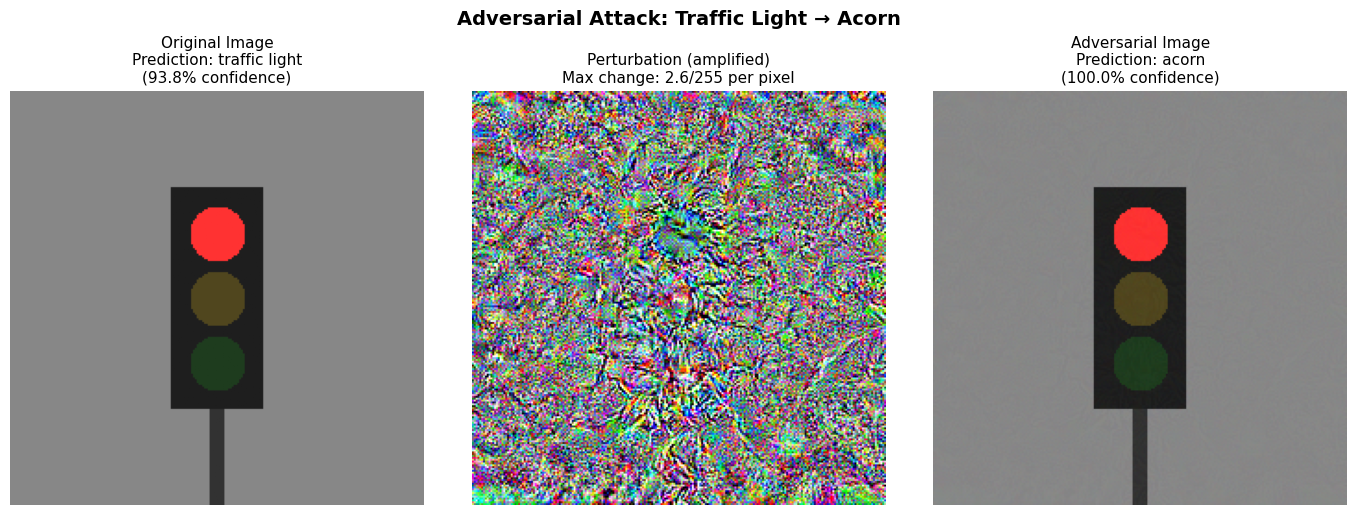


Figure saved as 'adversarial_attack_demo.png'


In [11]:
# Create the comparison figure
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Original image
axes[0].imshow(np.clip(orig_np, 0, 1))
axes[0].set_title(f'Original Image\nPrediction: {imagenet_labels[orig_pred_class]}\n({orig_probs[orig_pred_class].item()*100:.1f}% confidence)', 
                  fontsize=11)
axes[0].axis('off')

# Perturbation (scaled for visibility)
pert_vis = (perturbation - perturbation.min()) / (perturbation.max() - perturbation.min() + 1e-8)
axes[1].imshow(pert_vis)
axes[1].set_title(f'Perturbation (amplified)\nMax change: {np.abs(perturbation).max()*255:.1f}/255 per pixel', 
                  fontsize=11)
axes[1].axis('off')

# Adversarial image
axes[2].imshow(np.clip(adv_np, 0, 1))
axes[2].set_title(f'Adversarial Image\nPrediction: {imagenet_labels[adv_pred]}\n({adv_probs[adv_pred].item()*100:.1f}% confidence)', 
                  fontsize=11)
axes[2].axis('off')

plt.suptitle(f'Adversarial Attack: Traffic Light → {imagenet_labels[adv_pred].title()}', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('adversarial_attack_demo.png', dpi=150, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()

print("\nFigure saved as 'adversarial_attack_demo.png'")

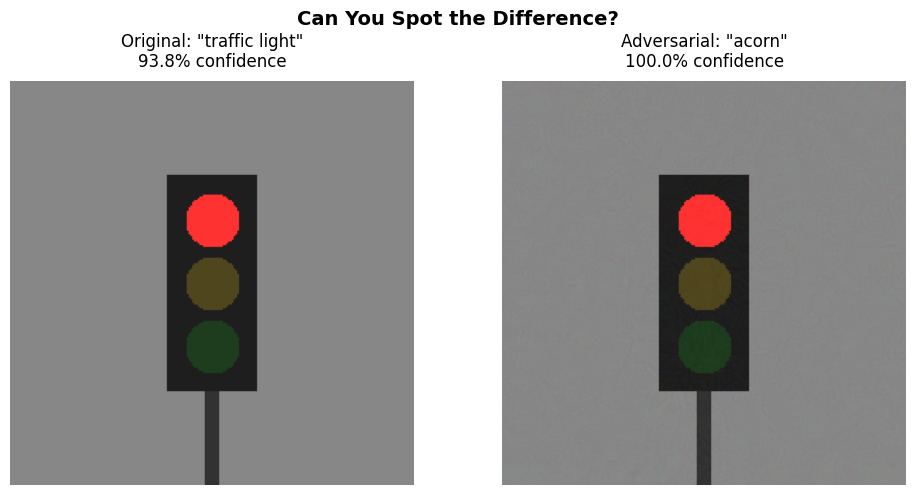

Figure saved as 'adversarial_comparison.png'


In [12]:
# Create a side-by-side comparison without the perturbation
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(np.clip(orig_np, 0, 1))
axes[0].set_title(f'Original: "{imagenet_labels[orig_pred_class]}"\n{orig_probs[orig_pred_class].item()*100:.1f}% confidence', 
                  fontsize=12, pad=10)
axes[0].axis('off')

axes[1].imshow(np.clip(adv_np, 0, 1))
axes[1].set_title(f'Adversarial: "{imagenet_labels[adv_pred]}"\n{adv_probs[adv_pred].item()*100:.1f}% confidence', 
                  fontsize=12, pad=10)
axes[1].axis('off')

plt.suptitle('Can You Spot the Difference?', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('adversarial_comparison.png', dpi=150, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

print("Figure saved as 'adversarial_comparison.png'")

## Understanding the Attack

The perturbation we added is tiny — typically less than 1-2% change per pixel. To the human eye, the two images look identical. But to the neural network, that small noise pattern is enough to completely change its classification.

This works because neural networks don't "see" the way we do. They're exquisitely sensitive to specific patterns in pixel space that have no semantic meaning to humans. The attack finds a direction in that high-dimensional space where a small step dramatically changes the output.

In [13]:
# Quantify the perturbation
l_inf = np.abs(perturbation).max()
l_2 = np.sqrt((perturbation**2).sum())
mean_change = np.abs(perturbation).mean()

print("Perturbation Statistics:")
print(f"  L∞ norm (max change): {l_inf:.4f} ({l_inf*255:.2f}/255 per channel)")
print(f"  L2 norm (total energy): {l_2:.4f}")
print(f"  Mean absolute change: {mean_change:.4f} ({mean_change*255:.2f}/255)")
print(f"\nAs percentage of full intensity:")
print(f"  Max change: {l_inf*100:.2f}%")
print(f"  Mean change: {mean_change*100:.3f}%")

Perturbation Statistics:
  L∞ norm (max change): 0.0100 (2.55/255 per channel)
  L2 norm (total energy): 2.4348
  Mean absolute change: 0.0054 (1.38/255)

As percentage of full intensity:
  Max change: 1.00%
  Mean change: 0.542%


## Implications for Safety-Critical Systems

This simple demonstration shows why adversarial robustness matters for systems deployed in the real world. An autonomous vehicle that mistakes a traffic light for a tree could have catastrophic consequences.

Research in certified robustness aims to provide mathematical guarantees that a model's prediction won't change within some perturbation bound — ensuring that no adversarial attack below that threshold can succeed.